In [48]:
# https://www.mathsisfun.com/algebra/matrix-transform.html
# bai 7

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import math as m

In [50]:
# Ex1
A = np.array([[2,2],
              [2,3]])

b = np.array([4,6])

lst = np.linalg.lstsq(A, b, rcond=None)[0]

left_side = A.T @ A @ lst
right_side = A.T @ np.reshape(b, (2, -1))

right_side = np.reshape(right_side, (1,-1))[0]

print("lest square:",lst, end="\n------------------\n")
print("A.T @ A @ x:", left_side, end="\n------------------\n")
print("A.T @ b:", right_side, end="\n------------------\n")

lest square: [-1.49191557e-16  2.00000000e+00]
------------------
A.T @ A @ x: [20. 26.]
------------------
A.T @ b: [20 26]
------------------


In [51]:
# Ex2
A = np.array([[0,0,1],
              [0,1,1],
              [1,2,1],
              [1,0,1],
              [4,1,1],
              [4,2,1]])

b = np.array([0.5,1.6,2.8,0.8,5.1,5.9])

lst = np.linalg.lstsq(A,b, rcond=None)[0]

left_side = A.T @ A @ lst
right_side = A.T @ b

right_side = np.reshape(right_side, (1,-1))[0]

print("lest square:",lst, end="\n------------------\n")
print("A.T @ A @ x:", left_side, end="\n------------------\n")
print("A.T @ b:", right_side, end="\n------------------\n")

lest square: [0.9275 0.9225 0.315 ]
------------------
A.T @ A @ x: [47.6 24.1 16.7]
------------------
A.T @ b: [47.6 24.1 16.7]
------------------


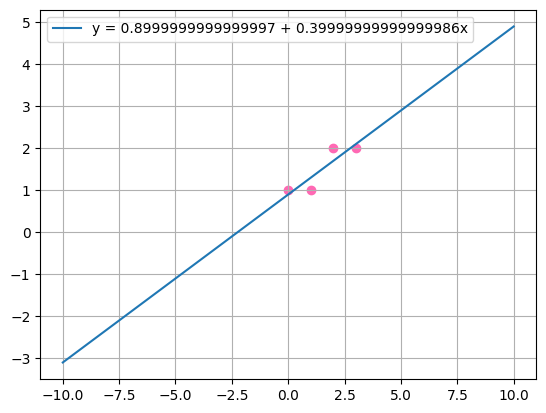

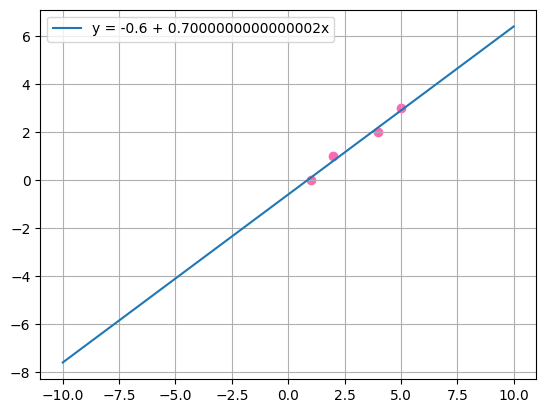

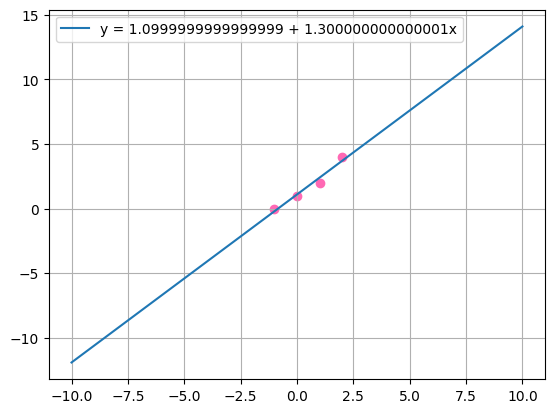

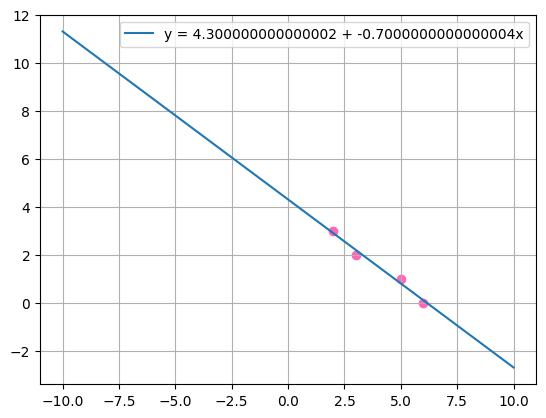

In [52]:
# Ex3
def getX_Y(*vectors):
  x = [vector[0] for vector in vectors]
  y = [vector[1] for vector in vectors]
  return np.array(x),np.array(y)

def get_a0_a1(*vectors):
  x,y = getX_Y(*vectors)
  x = np.vstack([x, np.ones(len(x))]).T
  a1, a0 = np.linalg.lstsq(x, y, rcond=None)[0]
  return a0, a1

def draw_2D(a0,a1,*vectors):
  v1,v2 = getX_Y(*vectors)
  x = np.linspace(-10,10,400)
  y = a0 + a1*x
  plt.plot(x, y, label=f"y = {a0} + {a1}x")
  plt.scatter(v1,v2, color='hotpink')
  plt.legend()
  plt.grid()
  plt.show()

# a
v1,v2,v3,v4 = [0,1], [1,1], [2,2], [3,2]
a0, a1 = get_a0_a1(v1,v2,v3,v4)
draw_2D(a0, a1, v1,v2,v3,v4)

# b
v1,v2,v3,v4 = [1,0], [2,1], [4,2], [5,3]
a0, a1 = get_a0_a1(v1,v2,v3,v4)
draw_2D(a0, a1, v1,v2,v3,v4)

# c
v1,v2,v3,v4 = [-1,0], [0,1], [1,2], [2,4]
a0, a1 = get_a0_a1(v1,v2,v3,v4)
draw_2D(a0, a1, v1,v2,v3,v4)

# d
v1,v2,v3,v4 = [2,3], [3,2], [5,1], [6,0]
a0, a1 = get_a0_a1(v1,v2,v3,v4)
draw_2D(a0, a1, v1,v2,v3,v4)

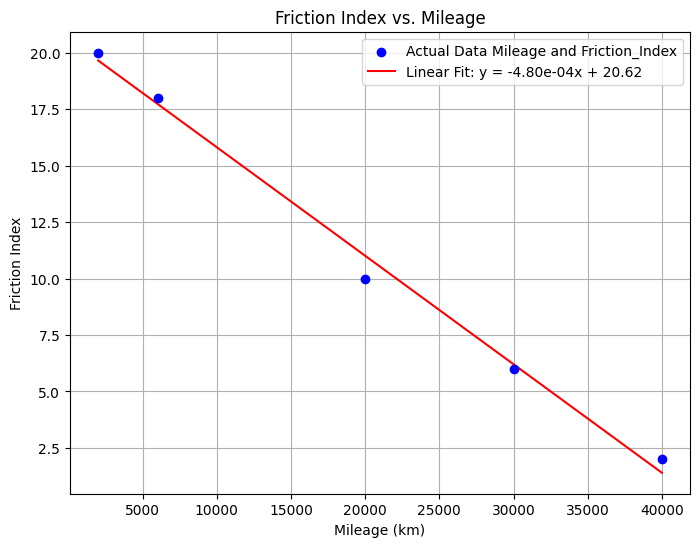

In [53]:
# Ex4
# ax + b = y
Mileage = np.array([2000, 6000, 20000, 30000, 40000]) # x
Friction_Index = np.array([20,18,10,6,2]) # y

x = np.vstack([Mileage, np.ones(len(Mileage))]).T
a, b = np.linalg.lstsq(x, Friction_Index, rcond=None)[0]

y = a*Mileage + b

plt.figure(figsize=(8, 6))
plt.scatter(Mileage, Friction_Index, color='blue', label='Actual Data Mileage and Friction_Index', zorder=3)
plt.plot(Mileage, y, color='red', label=f'Linear Fit: y = {a:.2e}x + {b:.2f}')
plt.title('Friction Index vs. Mileage')
plt.xlabel('Mileage (km)')
plt.ylabel('Friction Index')
plt.legend()
plt.grid()
plt.show()

In [54]:
# Ex5
x = np.array([1, 2, 3])  # x-values
y = np.array([7.9, 5.4, -9])  # y-values

M = np.column_stack((np.cos(x), np.sin(x)))

coefficients = np.linalg.lstsq(M, y, rcond=None)[0]

A, B = coefficients

print(f"A = {A}")
print(f"B = {B}")
print(f"Least-squares fit: y = {A:.4f}cos(x) + {B:.4f}sin(x)")

A = 7.868451951085348
B = 6.937876917573625
Least-squares fit: y = 7.8685cos(x) + 6.9379sin(x)


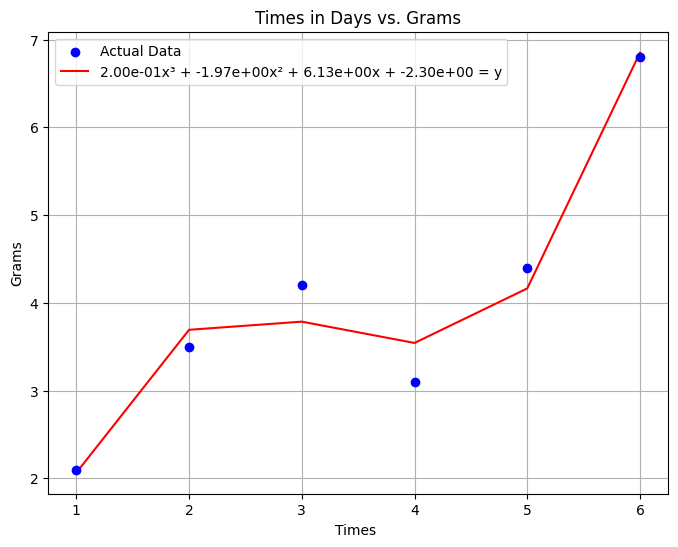

In [55]:
# Ex6
time_in_days = np.array([1,2,3,4,5,6])

x = np.array([[1,1,1,1],
              [8,4,2,1],
              [27,9,3,1],
              [64,16,4,1],
              [125,25,5,1],
              [216,36,6,1]])

grams = np.array([2.1, 3.5, 4.2, 3.1, 4.4, 6.8])

a,b,c,d = np.linalg.lstsq(x, grams, rcond=None)[0]

y = (a*time_in_days**3) + (b*time_in_days**2) + (c*time_in_days) + d

plt.figure(figsize=(8, 6))
plt.scatter(time_in_days, grams, color='blue', label='Actual Data', zorder=3)
plt.plot(time_in_days, y, color='red', label=f'{a:.2e}x³ + {b:.2e}x² + {c:.2e}x + {d:.2e} = y')
plt.title('Times in Days vs. Grams')
plt.xlabel('Times ')
plt.ylabel('Grams')
plt.legend()
plt.grid()
plt.show()

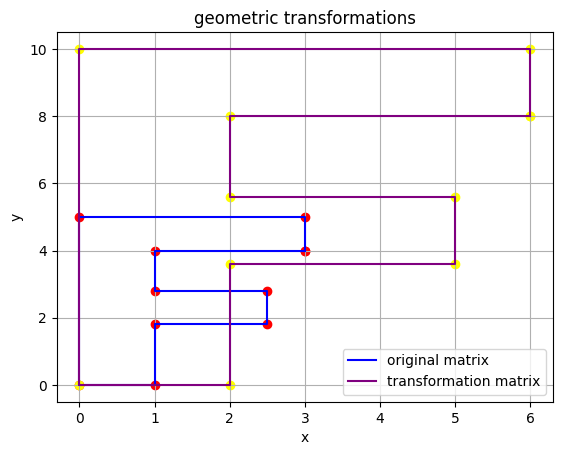

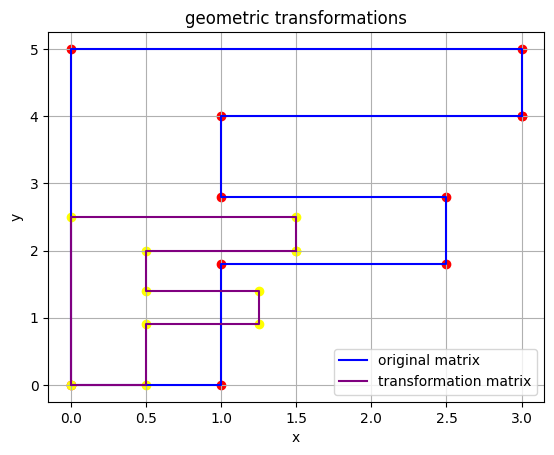

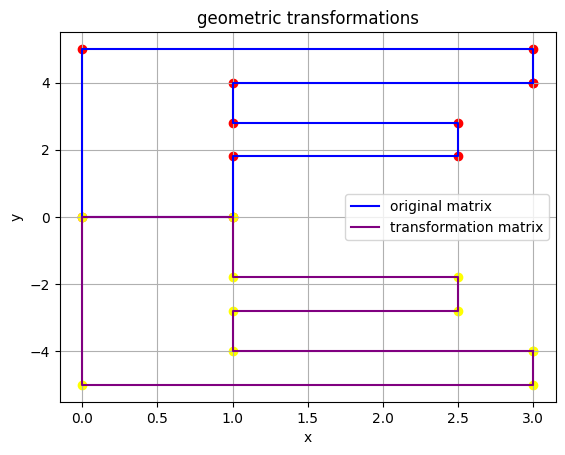

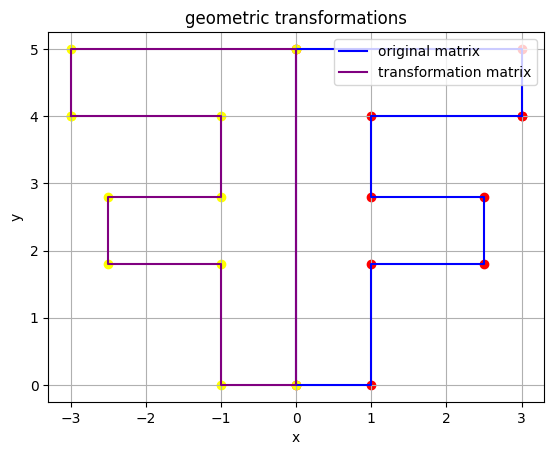

In [56]:
# Ex7
def geometric_transformations(F, trans_matrix):
  x = [coordinate[0] for coordinate in F]
  y = [coordinate[1] for coordinate in F]

  x_trans = [coordinate[0] for coordinate in trans_matrix]
  y_trans = [coordinate[1] for coordinate in trans_matrix]

  # plot F
  plt.plot(x, y, color="blue", label="original matrix")
  plt.scatter(x, y, color='red')

  # plot trans_matrix
  plt.plot(x_trans, y_trans, color="purple", label="transformation matrix")
  plt.scatter(x_trans, y_trans, color='yellow')

  plt.title("geometric transformations")
  plt.xlabel("x")
  plt.ylabel("y")
  plt.legend()
  plt.grid()
  plt.show()

def transformation(F, S):
  a,b,c,d = S.ravel()
  trans_matrix = []
  for i in range(len(F)):
    point_F = F[i]
    x = a * point_F[0] + b * point_F[1]
    y = c * point_F[0] + d * point_F[1]
    trans_matrix.append([x,y])

  return trans_matrix


F = [[3, 4], [3, 5], [0, 5], [0, 0], [1, 0], [1, 1.8], [2.5, 1.8], [2.5, 2.8], [1, 2.8], [1, 4], [3, 4]]
F = np.array(F)

# a
S = np.array([[2, 0],
              [0, 2]])

trans_matrix = transformation(F,S)
geometric_transformations(F, trans_matrix)

# b
S = np.array([[0.5, 0],
              [0, 0.5]])
trans_matrix = transformation(F,S)
geometric_transformations(F, trans_matrix)

# c
S = np.array([[1, 0],
              [0, -1]])
trans_matrix = transformation(F,S)
geometric_transformations(F, trans_matrix)

# d
S = np.array([[-1, 0],
              [0, 1]])
trans_matrix = transformation(F,S)
geometric_transformations(F, trans_matrix)

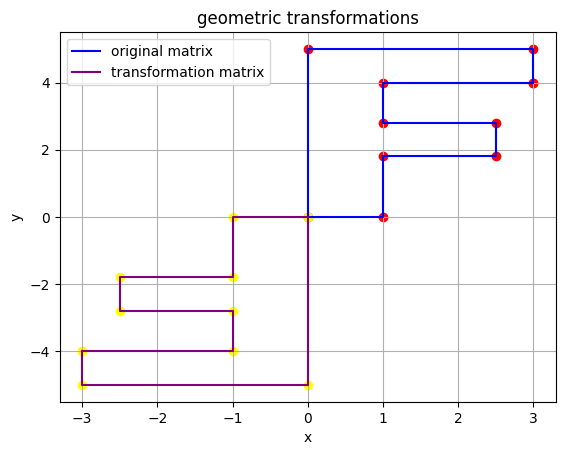

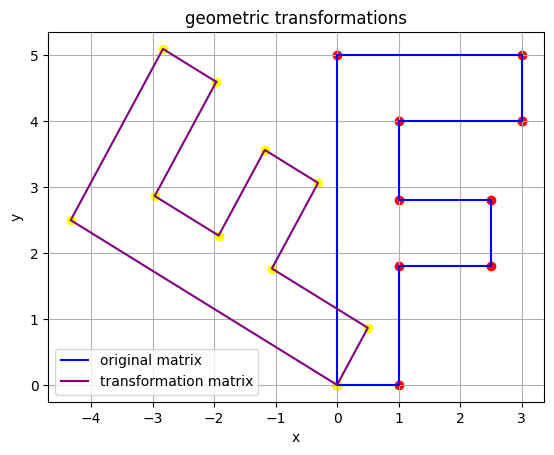

In [57]:
# Ex8
# a
pi = m.pi
S = np.array([[m.cos(pi), -m.sin(pi)],
              [m.sin(pi), m.cos(pi)]])

trans_matrix = transformation(F,S)
geometric_transformations(F, trans_matrix)

# b
pi = m.pi/3
S = np.array([[m.cos(pi), -m.sin(pi)],
              [m.sin(pi), m.cos(pi)]])

trans_matrix = transformation(F,S)
geometric_transformations(F, trans_matrix)

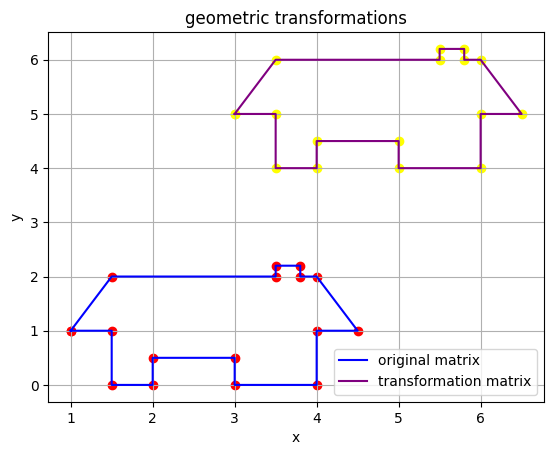

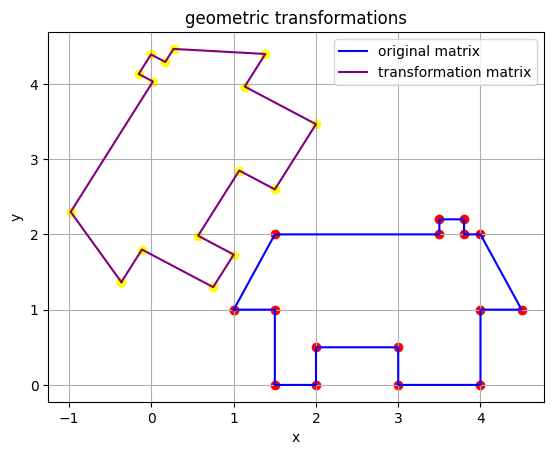

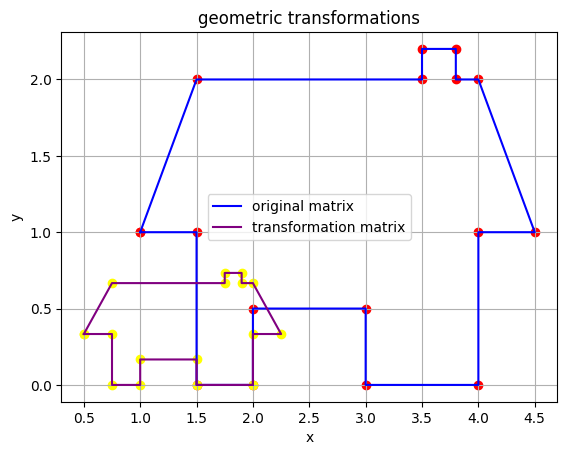

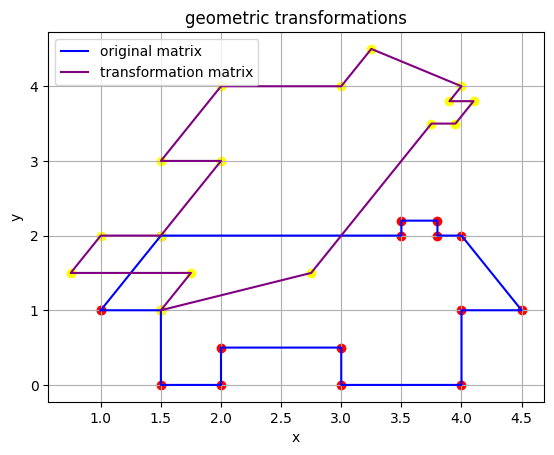

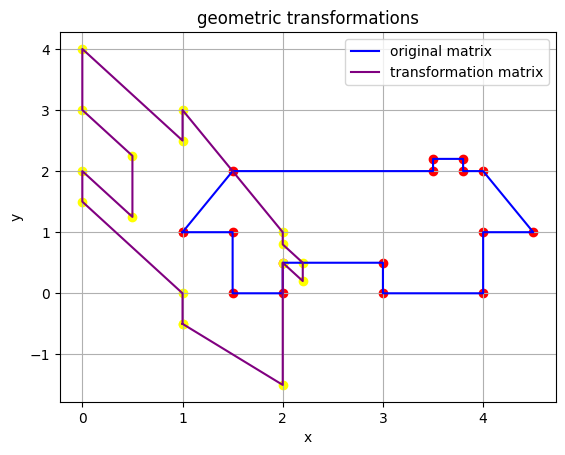

In [58]:
# Ex9
def translation(init_coordinate, tx, ty):
  trans_matrix = []
  for i in range(len(init_coordinate)):
    point = init_coordinate[i]
    x = point[0] + tx
    y = point[1] + ty
    trans_matrix.append([x,y])
  return trans_matrix


def scaling(init_coordinate, sx, sy):
  trans_matrix = []
  for i in range(len(init_coordinate)):
    point = init_coordinate[i]
    x = point[0] / sx
    y = point[1] / sy
    trans_matrix.append([x,y])
  return trans_matrix


House = np.array([[1, 1],[1.5, 1],[1.5, 0],[2, 0],[2, 0.5],[3, 0.5],[3, 0],
                  [4, 0],[4, 1],[4.5, 1],[4, 2],[3.8, 2],[3.8, 2.2],[3.5, 2.2],
                  [3.5, 2],[1.5, 2],[1, 1]])

# a
tx, ty = 2, 4
trans_matrix = translation(House, tx, ty)
geometric_transformations(House, trans_matrix)

# b
pi = m.pi/3
S = np.array([[m.cos(pi), -m.sin(pi)],
              [m.sin(pi), m.cos(pi)]])

trans_matrix = transformation(House, S)
geometric_transformations(House, trans_matrix)

# c
sx, sy = 2, 3
trans_matrix = scaling(House, sx, sy)
geometric_transformations(House, trans_matrix)

# d
# shear x
shear_x = 0.5
S = np.array([[shear_x, 1],
              [1, 0]])

trans_matrix = transformation(House, S)
geometric_transformations(House, trans_matrix)

# shear y
shear_y = -1.5
S = np.array([[0, 1],
              [1, shear_y]])
trans_matrix = transformation(House, S)
geometric_transformations(House, trans_matrix)

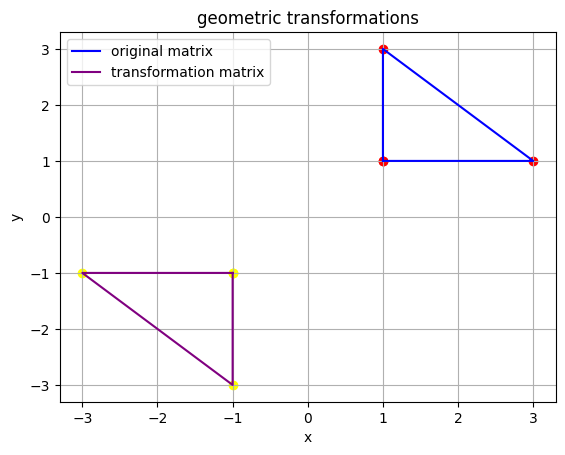

In [59]:
# Ex10
P = [1,1]
Q = [3,1]
R = [1,3]

A = np.array([P,Q,R,P])
I = -np.eye(len(A))

transform_point = I @ A
geometric_transformations(A, transform_point)

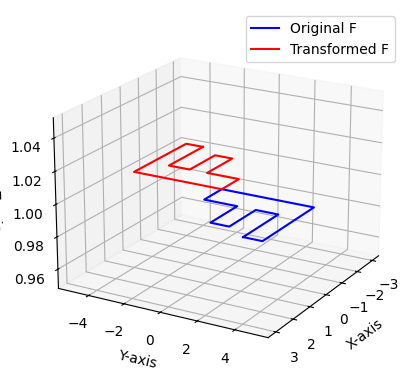

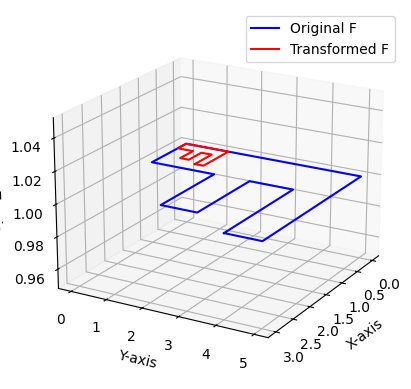

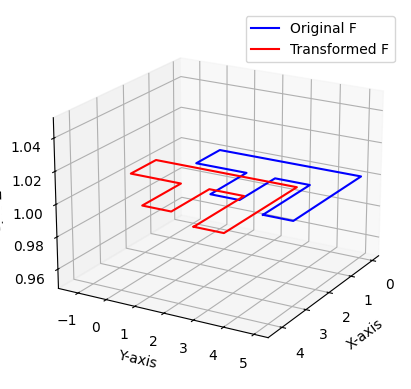

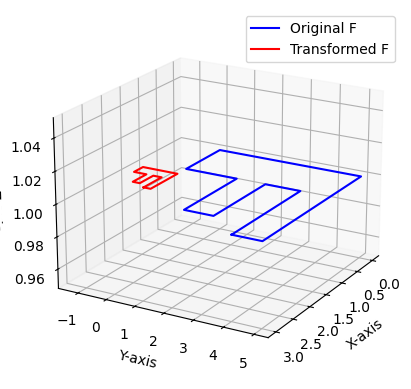

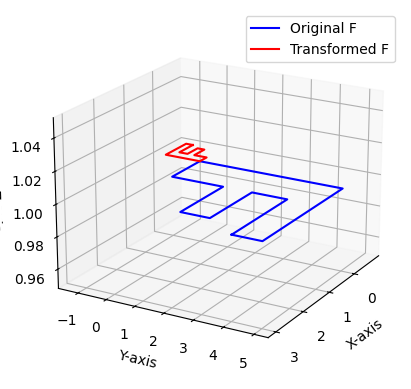

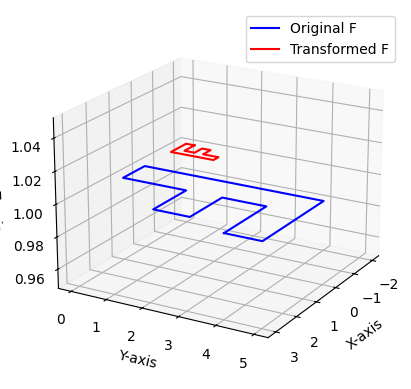

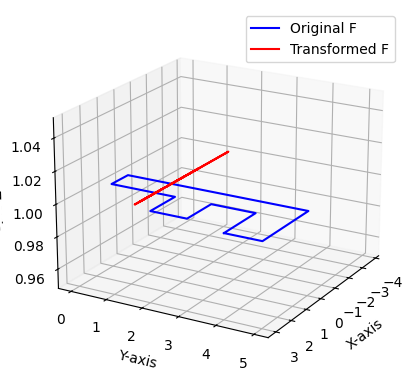

In [72]:
# Ex 11
# a
def draw_3D(F_3D, new_F3D):
  x_F, y_F, Z_F = F_3D[:, 0], F_3D[:, 1], F_3D[:, 2]
  x_FN, y_FN, Z_FN = new_F3D[:, 0], new_F3D[:, 1], new_F3D[:, 2]

  fig = plt.figure()
  ax = fig.add_subplot(111, projection='3d')

  ax.plot(x_F, y_F, Z_F, color='blue', label="Original F")
  ax.plot(x_FN, y_FN, Z_FN, color='red', label="Transformed F")

  ax.view_init(elev=20, azim=30)  # Cải thiện góc nhìn của đồ thị

  ax.set_xlabel('X-axis')
  ax.set_ylabel('Y-axis')
  ax.set_zlabel('Z-axis')
  ax.legend()
  plt.show()


def transformation_3D(F_3D, trans_matrix):
  matrix = []
  row1, row2, row3 = trans_matrix
  for i in range(len(F_3D)):
    point = F_3D[i]
    x = np.dot(point, row1)
    y = np.dot(point, row2)
    z = np.dot(point, row3)
    matrix.append([x,y,z])

  return np.array(matrix)


def Execute_a(T, F_3D):
  for T_i in T:
    new_F3D = transformation_3D(F_3D, T_i)
    draw_3D(F_3D, new_F3D)


F_3D = np.column_stack((F, np.ones(len(F))))

T1 = np.array([[-1,0,0],
               [0,-1,0],
               [0,0,1]])

T2 = np.array([[1/4,0,0],
               [0,1/4,0],
               [0,0,1]])

T3 = np.array([[1,0,5/4],
               [0,1,-5/4],
               [0,0,1]])

T4 = np.array([[1/4,0,5/4],
               [0,1/4,-5/4],
               [0,0,1]])

T5 = np.array([[-1/4,0,0],
               [0,-1/4,0],
               [0,0,1]])

T6 = np.array([[-1/4,0,-5/4],
               [0,-1/4,5/4],
               [0,0,1]])

T7 = np.array([[1,-1,5/4],
               [0,0,5/4],
               [0,0,1]])

T = [T1, T2, T3, T4, T5, T6, T7]
Execute_a(T, F_3D)

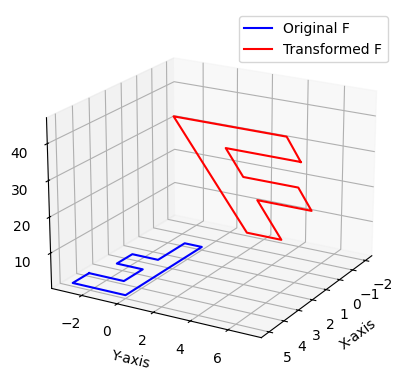

In [73]:
# Ex 11
# b
def rotation(theta, coordinates):
  R = np.array([[m.cos(theta), -m.sin(theta)],
                [m.sin(theta), m.cos(theta)]])
  trans_matrix = []
  row1 = R[0]
  row2 = R[1]
  for i in range(len(coordinates)):
    point = coordinates[i]
    x = np.dot(row1, point)
    y = np.dot(row2, point)
    trans_matrix.append([x,y])

  return np.array(trans_matrix)


theta = 3*m.pi/2
Diagram2 = rotation(theta, F)

T = np.array([[1,0,-2],
              [0,-2,1],
              [9,0,1]])

Diagram2_3D = np.column_stack((Diagram2, np.ones(len(Diagram2))))
trans_Diagram2_3D = transformation_3D(Diagram2_3D, T)
draw_3D(Diagram2_3D, trans_Diagram2_3D)